# RLHF Results Visualization

In [27]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [28]:
# ============================================
# Configuration
# ============================================
task = 'toxicity'  # Options: toxicity, imdb
model = 'gpt-neo-2.7B'  # Model shorthand
out_dir = "/scratch/pbb/Project/Gradient-Streaming/RLHF"
lr_config_path = "/home/pbb/Project/Gradient-Streaming/RLHF/train/lr/config.json"

# Configuration used for experiments
# Note: seed is auto-discovered from available experiment directories
default_config = {
    'batch_size': 256,
    # Validation settings (for data selection)
    'n_val': 1024,
    'val_batch_size': 64,
    # PPO settings
    'ppo_epochs': 4,
    'mini_batch_size': 8,
    'init_kl_coef': 0.1,
    # Learning rates are loaded from config.json per experiment
    # Fallback values used only if config lookup fails (matching train.sh)
    'lr_full_fallback': '1e-6',
    'lr_lora_fallback': '1e-5',
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")
else:
    print(f"Warning: LR config not found at {lr_config_path}, using fallback LRs")

# ============================================
# Method Definitions (matching train.sh)
# ============================================
# Format: (selection, compression, training_type, use_second_order)
methods = {
    # Baselines (NA-NA): no selection, no compression
    'NA-NA-Full': ('NA', 'NA', 'Full', False),
    'NA-NA-LoRA': ('NA', 'NA', 'LoRA', False),

    # Streaming without compression (per-layer selection)
    'Streaming-NA-Full': ('Streaming', 'NA', 'Full', False),
    'Streaming-NA-LoRA': ('Streaming', 'NA', 'LoRA', False),

    # GREATS without compression (global selection)
    'GREATS-NA-Full': ('GREATS', 'NA', 'Full', False),
    'GREATS-NA-LoRA': ('GREATS', 'NA', 'LoRA', False),

    # Streaming with compression (MeSO optimizer)
    'Streaming-LoGra-Full': ('Streaming', 'LoGra', 'Full', False),

    # GREATS with compression (MeSO optimizer)
    'GREATS-LoGra-Full': ('GREATS', 'LoGra', 'Full', False),
}

print(f"\nDefined {len(methods)} methods:")
for name in methods:
    print(f"  - {name}")

Loaded LR config from /home/pbb/Project/Gradient-Streaming/RLHF/train/lr/config.json

Defined 8 methods:
  - NA-NA-Full
  - NA-NA-LoRA
  - Streaming-NA-Full
  - Streaming-NA-LoRA
  - GREATS-NA-Full
  - GREATS-NA-LoRA
  - Streaming-LoGra-Full
  - GREATS-LoGra-Full


## Load Training Results

In [29]:
def lookup_lr(method_name, config_key, training_type):
    """
    Look up learning rate from lr_config.json.

    Args:
        method_name: e.g., 'NA-NA-Full', 'Streaming-LoGra-Full'
        config_key: e.g., 'toxicity'
        training_type: 'Full' or 'LoRA'

    Returns:
        LR as string (e.g., '1e-05')
    """
    if lr_config and config_key in lr_config:
        entry = lr_config[config_key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            if lr_val < 0.001:
                return f'{lr_val:.0e}'
            else:
                return f'{lr_val}'

    if training_type == 'LoRA':
        return default_config['lr_lora_fallback']
    else:
        return default_config['lr_full_fallback']


def build_job_name(method_name, lr, seed, config=None):
    """
    Build the job name for an experiment.

    New format (matching train.sh):
    {task}-{model}-{method_str}-{training_type}-lr{lr}-b{batch}-{val_str}-pe{ppo_epochs}-mb{mini_batch_size}-kl{kl_coef}-s{seed}

    Where:
    - method_str: {selection}-{compression}[-2nd]
    - val_str: v{n_val}[b{val_batch_size}] (b suffix only if n_val > 0)
    """
    if method_name not in methods:
        return None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = config or default_config
    batch_size = cfg['batch_size']
    n_val = cfg.get('n_val', 0)
    val_batch_size = cfg.get('val_batch_size', 1)
    ppo_epochs = cfg.get('ppo_epochs', 4)
    mini_batch_size = cfg.get('mini_batch_size', 8)
    init_kl_coef = cfg.get('init_kl_coef', 0.1)

    # Build method string
    compression_name = compression if compression else 'NA'
    method_str = f"{selection}-{compression_name}"
    if use_second_order:
        method_str = f"{method_str}-2nd"

    # Build validation string
    val_str = f"v{n_val}"
    if n_val > 0:
        val_str = f"{val_str}b{val_batch_size}"

    # Build full job name
    job_name = f"{task}-{model}-{method_str}-{training_type}-lr{lr}-b{batch_size}-{val_str}-pe{ppo_epochs}-mb{mini_batch_size}-kl{init_kl_coef}-s{seed}"

    return job_name


def build_experiment_dir_pattern(method_name, config=None):
    """
    Build a glob pattern to find all seeds for an experiment.
    Returns (pattern, base_dir_prefix) where the pattern matches seed variations.
    """
    if method_name not in methods:
        return None, None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = config or default_config
    batch_size = cfg['batch_size']
    n_val = cfg.get('n_val', 0)
    val_batch_size = cfg.get('val_batch_size', 1)
    ppo_epochs = cfg.get('ppo_epochs', 4)
    mini_batch_size = cfg.get('mini_batch_size', 8)
    init_kl_coef = cfg.get('init_kl_coef', 0.1)

    # Look up LR
    lr = lookup_lr(method_name, task, training_type)

    # Build method string
    compression_name = compression if compression else 'NA'
    method_str = f"{selection}-{compression_name}"
    if use_second_order:
        method_str = f"{method_str}-2nd"

    # Build validation string
    val_str = f"v{n_val}"
    if n_val > 0:
        val_str = f"{val_str}b{val_batch_size}"

    # Build directory pattern with wildcard for seed
    dir_pattern = f"{task}-{model}-{method_str}-{training_type}-lr{lr}-b{batch_size}-{val_str}-pe{ppo_epochs}-mb{mini_batch_size}-kl{init_kl_coef}-s*"
    base_prefix = f"{task}-{model}-{method_str}-{training_type}-lr{lr}-b{batch_size}-{val_str}-pe{ppo_epochs}-mb{mini_batch_size}-kl{init_kl_coef}-s"

    return f"{out_dir}/{dir_pattern}", base_prefix


def discover_seeds(method_name, config=None):
    """
    Discover all available seeds for a given experiment setup.
    Returns a sorted list of seed values found.
    """
    pattern, base_prefix = build_experiment_dir_pattern(method_name, config)
    if pattern is None:
        return []

    # Find matching directories
    matching_dirs = glob(pattern)

    # Extract seeds from directory names
    seeds = []
    seed_pattern = re.compile(r'-s(\d+)$')
    for dir_path in matching_dirs:
        dir_name = Path(dir_path).name
        match = seed_pattern.search(dir_name)
        if match:
            seeds.append(int(match.group(1)))

    return sorted(seeds)


def build_experiment_path(method_name, seed, config=None):
    """
    Build the experiment directory path for a specific seed.

    New directory format:
    {task}-{model}-{method_str}-{training_type}-lr{lr}-b{batch}-{val_str}-pe{ppo_epochs}-mb{mini_batch_size}-kl{kl_coef}-s{seed}
    """
    if method_name not in methods:
        return None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = config or default_config

    # Look up LR
    lr = lookup_lr(method_name, task, training_type)

    # Build job name
    job_name = build_job_name(method_name, lr, seed, cfg)
    if job_name is None:
        return None

    return f"{out_dir}/{job_name}"


def load_training_history(history_path):
    """
    Load training results from training_history.json (preferred method).

    This file is saved at the end of training and contains all metrics
    tracked via _update_history().

    History field names (from trainer.py _update_history):
    - 'loss': total loss
    - 'reward': mean reward (reward/mean)
    - 'kl': KL divergence (objective/kl)
    - 'toxicity_prob': batch toxicity (eval/toxicity_prob)
    - 'full_eval_toxicity_prob': evaluation toxicity
    - 'full_eval_steps': evaluation step numbers

    Returns dict with arrays matching the log parser format.
    """
    with open(history_path, 'r') as f:
        history = json.load(f)

    # Convert history format to our standard format
    # Note: history uses 'reward' not 'reward_mean'
    n_points = len(history.get('reward', []))

    return {
        'steps': np.arange(n_points),  # Steps are implicit in history
        'reward_mean': np.array(history.get('reward', [])),  # History uses 'reward'
        'kl': np.array(history.get('kl', [])),
        'batch_toxicity': np.array(history.get('toxicity_prob', [])),
        'eval_toxicity_steps': np.array(history.get('full_eval_steps', [])),
        'eval_toxicity': np.array(history.get('full_eval_toxicity_prob', [])),
    }


def parse_key_value_format(line):
    """
    Parse old-style key=value log format.
    Example: "Step 10: loss=0.123 reward=0.45 kl=0.032 tox=0.076"

    Returns dict with standardized metric names.
    """
    metrics = {}

    # Extract key=value pairs using regex
    # Matches: word=number (including negative and scientific notation)
    pattern = r'(\w+)=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)'
    matches = re.findall(pattern, line)

    for key, value in matches:
        val = float(value)
        # Map short names to full metric names
        if key == 'reward':
            metrics['reward/mean'] = val
        elif key == 'kl':
            metrics['objective/kl'] = val
        elif key == 'tox':
            metrics['eval/toxicity_prob'] = val
        elif key == 'loss':
            metrics['loss/total'] = val
        elif key == 'clipfrac':
            metrics['policy/clipfrac'] = val
        else:
            metrics[key] = val

    return metrics


def load_training_log(log_path):
    """
    Parse training log to extract metrics over time (fallback method).

    Supports two formats:
    1. New format with dict: "Step 10: loss=0.123 ... {'reward/mean': 0.45, ...}"
    2. Old format key=value only: "Step 10: loss=0.123 reward=0.45 kl=0.032 tox=0.076"

    Returns dict with arrays of:
    - steps
    - reward_mean
    - kl: KL divergence (objective/kl)
    - batch_toxicity: Toxicity measured on PPO training batch generations.
    - eval_toxicity: Toxicity measured on held-out evaluation prompts.
    """
    steps = []
    rewards = []
    kl_values = []
    batch_toxicity = []
    eval_toxicity = []
    eval_toxicity_steps = []

    with open(log_path, 'r') as f:
        for line in f:
            # Parse training step lines
            if 'Step ' in line and 'Eval step' not in line:
                try:
                    # Extract step number
                    step_match = re.search(r'Step (\d+):', line)
                    if not step_match:
                        continue
                    step = int(step_match.group(1))

                    metrics = None

                    # Try new format first (with dict)
                    if '{' in line:
                        try:
                            dict_str = line[line.index('{'):line.rindex('}')+1]
                            dict_str = dict_str.replace("'", '"')
                            metrics = json.loads(dict_str)
                        except (ValueError, json.JSONDecodeError):
                            pass

                    # Fall back to old key=value format
                    if metrics is None:
                        metrics = parse_key_value_format(line)

                    if metrics:
                        steps.append(step)
                        rewards.append(metrics.get('reward/mean', 0))
                        kl_values.append(metrics.get('objective/kl', 0))
                        batch_toxicity.append(metrics.get('eval/toxicity_prob', 0))

                except (ValueError, KeyError):
                    continue

            # Parse evaluation lines: "[Eval step 1] toxicity: 0.0561 (rate=3.0%)"
            elif '[Eval step' in line and 'toxicity:' in line:
                try:
                    match = re.search(r'\[Eval step (\d+)\] toxicity: ([\d.]+)', line)
                    if match:
                        step = int(match.group(1))
                        tox = float(match.group(2))
                        eval_toxicity_steps.append(step)
                        eval_toxicity.append(tox)
                except (ValueError, AttributeError):
                    continue

    return {
        'steps': np.array(steps),
        'reward_mean': np.array(rewards),
        'kl': np.array(kl_values),
        'batch_toxicity': np.array(batch_toxicity),
        'eval_toxicity_steps': np.array(eval_toxicity_steps),
        'eval_toxicity': np.array(eval_toxicity),
    }


def load_experiment_results(exp_path):
    """
    Load training results from an experiment directory.

    Prefers training_history.json (complete runs) over log parsing (incomplete runs).
    """
    history_path = f"{exp_path}/training_history.json"
    log_path = f"{exp_path}/train.log"

    # Prefer training_history.json (saved at end of training, has all metrics)
    if Path(history_path).exists():
        try:
            return load_training_history(history_path), 'history'
        except (json.JSONDecodeError, KeyError) as e:
            print(f"  Warning: Failed to load {history_path}: {e}")

    # Fall back to log parsing (for incomplete runs)
    if Path(log_path).exists():
        return load_training_log(log_path), 'log'

    return None, None


def load_multi_seed_results(method_name, config=None):
    """
    Load and aggregate results across all available seeds for a method.

    Returns a dict with:
    - steps: common steps across all seeds
    - reward_mean_mean, reward_mean_std
    - kl_mean, kl_std: KL divergence (objective/kl)
    - batch_toxicity_mean, batch_toxicity_std
    - eval_toxicity_steps, eval_toxicity_mean, eval_toxicity_std
    - n_seeds: number of seeds found
    - seeds: list of seeds used
    - source: 'history' or 'log' (how data was loaded)
    """
    seeds = discover_seeds(method_name, config)
    if not seeds:
        return None

    all_results = []
    valid_seeds = []
    sources = []

    for seed in seeds:
        path = build_experiment_path(method_name, seed, config)
        if path:
            result, source = load_experiment_results(path)
            if result is not None and len(result['steps']) > 0:
                all_results.append(result)
                valid_seeds.append(seed)
                sources.append(source)

    if not all_results:
        return None

    # Find common steps across all seeds (use the minimum length)
    min_len = min(len(r['steps']) for r in all_results)

    # Stack arrays for aggregation (truncate to common length)
    steps = all_results[0]['steps'][:min_len]
    reward_mean = np.stack([r['reward_mean'][:min_len] for r in all_results])
    kl = np.stack([r['kl'][:min_len] for r in all_results])
    batch_toxicity = np.stack([r['batch_toxicity'][:min_len] for r in all_results])

    # Handle eval toxicity (may have different lengths)
    eval_min_len = min(len(r['eval_toxicity']) for r in all_results) if all(len(r['eval_toxicity']) > 0 for r in all_results) else 0
    if eval_min_len > 0:
        eval_toxicity_steps = all_results[0]['eval_toxicity_steps'][:eval_min_len]
        eval_toxicity = np.stack([r['eval_toxicity'][:eval_min_len] for r in all_results])
        eval_toxicity_mean = np.mean(eval_toxicity, axis=0)
        eval_toxicity_std = np.std(eval_toxicity, axis=0)
    else:
        eval_toxicity_steps = np.array([])
        eval_toxicity_mean = np.array([])
        eval_toxicity_std = np.array([])

    # Determine primary source
    source = 'history' if 'history' in sources else 'log'

    return {
        'steps': steps,
        'reward_mean_mean': np.mean(reward_mean, axis=0),
        'reward_mean_std': np.std(reward_mean, axis=0),
        'kl_mean': np.mean(kl, axis=0),
        'kl_std': np.std(kl, axis=0),
        'batch_toxicity_mean': np.mean(batch_toxicity, axis=0),
        'batch_toxicity_std': np.std(batch_toxicity, axis=0),
        'eval_toxicity_steps': eval_toxicity_steps,
        'eval_toxicity_mean': eval_toxicity_mean,
        'eval_toxicity_std': eval_toxicity_std,
        'n_seeds': len(valid_seeds),
        'seeds': valid_seeds,
        'source': source,
    }


# Load all results with multi-seed aggregation
results = {}
print(f"Loading results for task: {task}")
print(f"Config: batch_size={default_config['batch_size']}, n_val={default_config['n_val']}, "
      f"val_batch_size={default_config['val_batch_size']}, ppo_epochs={default_config['ppo_epochs']}, "
      f"mini_batch_size={default_config['mini_batch_size']}, kl_coef={default_config['init_kl_coef']}")
print("=" * 60)

for method_name in methods.keys():
    data = load_multi_seed_results(method_name, default_config)
    if data:
        results[method_name] = data
        src_icon = "📁" if data['source'] == 'history' else "📝"
        print(f"+ {method_name}: {data['n_seeds']} seeds {data['seeds']}, {len(data['steps'])} points {src_icon}")
    else:
        # Try to discover what's available
        seeds = discover_seeds(method_name, default_config)
        if seeds:
            print(f"- {method_name}: Seeds found {seeds} but no valid results")
        else:
            print(f"- {method_name}: Not found")

print("=" * 60)
print(f"Loaded {len(results)}/{len(methods)} experiments")

Loading results for task: toxicity
Config: batch_size=256, n_val=1024, val_batch_size=64, ppo_epochs=4, mini_batch_size=8, kl_coef=0.1
- NA-NA-Full: Not found
+ NA-NA-LoRA: 1 seeds [42], 23 points 📝
- Streaming-NA-Full: Not found
+ Streaming-NA-LoRA: 1 seeds [42], 8 points 📝
- GREATS-NA-Full: Not found
+ GREATS-NA-LoRA: 1 seeds [42], 7 points 📝
- Streaming-LoGra-Full: Not found
- GREATS-LoGra-Full: Not found
Loaded 3/8 experiments


## Plot Training Curves

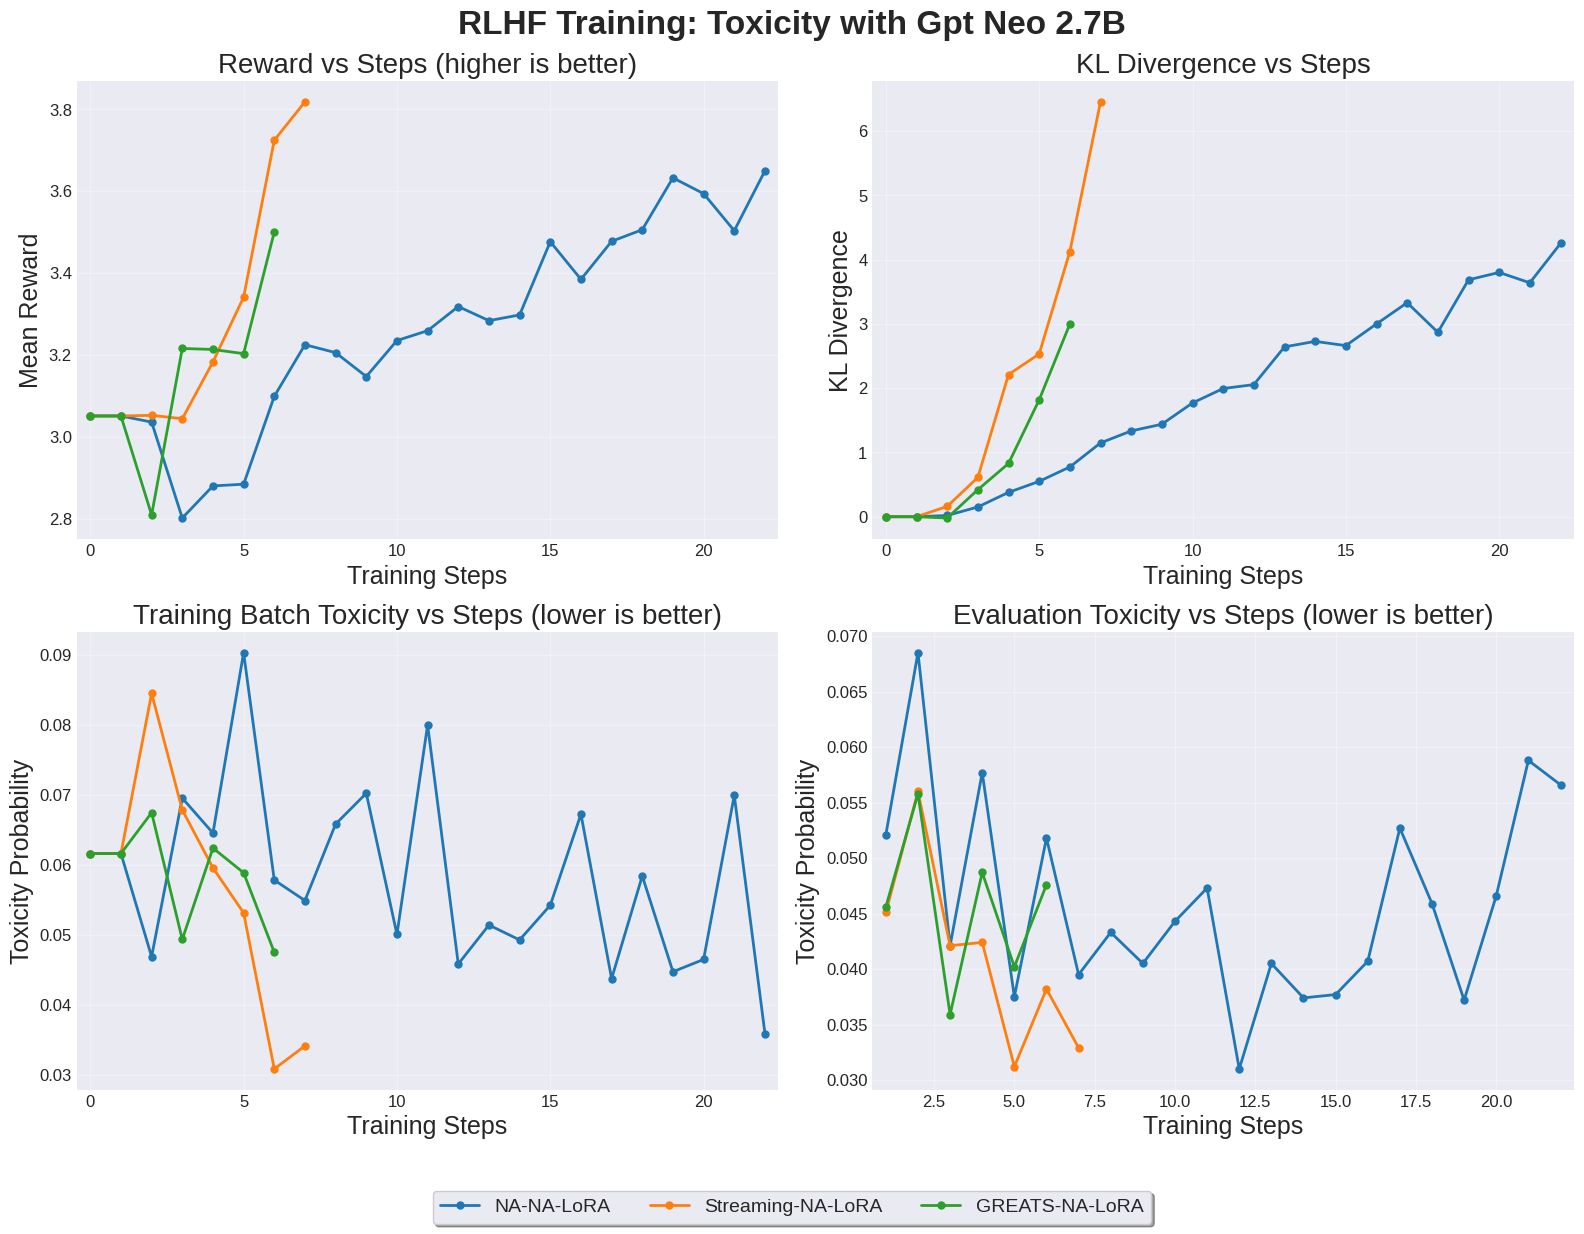

In [30]:
# Create 2x2 plot: Reward, KL Divergence, Batch Toxicity, Evaluation Toxicity
# Now with confidence intervals (shaded regions) for multi-seed results

model_name = model.replace('-', ' ').title()
task_name = task.title()

# Count total seeds across methods
total_seeds = set()
for data in results.values():
    total_seeds.update(data['seeds'])
plot_title = f"RLHF Training: {task_name} with {model_name}"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(plot_title, fontsize=24, fontweight='bold', y=0.98)

# Store handles and labels for unified legend
legend_handles = []
legend_labels = []


def plot_metric_with_ci(ax, x_data, y_mean, y_std, x_label, y_label, title, method_names, data_dict, collect_legend=False):
    """Helper to plot a metric with confidence intervals (shaded regions)."""
    for name in method_names:
        if name not in data_dict:
            continue
        data = data_dict[name]
        x = x_data(data)
        mean = y_mean(data)
        std = y_std(data)
        if x is None or len(x) == 0 or mean is None or len(mean) == 0:
            continue

        # Plot mean line with dot markers
        line, = ax.plot(x, mean, linewidth=2, marker='o', markersize=5, label=name)
        color = line.get_color()

        # Add shaded confidence interval (±1 std)
        if std is not None and len(std) > 0 and data['n_seeds'] > 1:
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        # Collect handles and labels for legend (only once)
        if collect_legend:
            legend_handles.append(line)
            legend_labels.append(name)

    ax.set_xlabel(x_label, fontsize=18)
    ax.set_ylabel(y_label, fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)


# Reward vs Steps
plot_metric_with_ci(
    axes[0, 0],
    x_data=lambda d: d['steps'],
    y_mean=lambda d: d['reward_mean_mean'],
    y_std=lambda d: d['reward_mean_std'],
    x_label='Training Steps',
    y_label='Mean Reward',
    title='Reward vs Steps (higher is better)',
    method_names=results.keys(),
    data_dict=results,
    collect_legend=True  # Collect legend from first plot
)

# KL Divergence vs Steps
plot_metric_with_ci(
    axes[0, 1],
    x_data=lambda d: d['steps'],
    y_mean=lambda d: d['kl_mean'],
    y_std=lambda d: d['kl_std'],
    x_label='Training Steps',
    y_label='KL Divergence',
    title='KL Divergence vs Steps',
    method_names=results.keys(),
    data_dict=results
)

# Training Batch Toxicity vs Steps
plot_metric_with_ci(
    axes[1, 0],
    x_data=lambda d: d['steps'],
    y_mean=lambda d: d['batch_toxicity_mean'],
    y_std=lambda d: d['batch_toxicity_std'],
    x_label='Training Steps',
    y_label='Toxicity Probability',
    title='Training Batch Toxicity vs Steps (lower is better)',
    method_names=results.keys(),
    data_dict=results
)

# Evaluation Toxicity vs Steps
plot_metric_with_ci(
    axes[1, 1],
    x_data=lambda d: d['eval_toxicity_steps'],
    y_mean=lambda d: d['eval_toxicity_mean'],
    y_std=lambda d: d['eval_toxicity_std'],
    x_label='Training Steps',
    y_label='Toxicity Probability',
    title='Evaluation Toxicity vs Steps (lower is better)',
    method_names=results.keys(),
    data_dict=results
)

# Add unified legend at the bottom of the figure
fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=min(len(legend_labels), 4),  # Up to 4 columns
    fontsize=14,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # Make room for legend
plt.show()

## Compare Final Performance

In [31]:
# Print final results with mean ± std across seeds
print(f"\n{'='*100}")
print(f"Final Training Results: {task}")
print(f"{'='*100}")
print(f"{'Method':<30} {'Seeds':<8} {'Reward':<22} {'Batch Tox':<22} {'Eval Tox':<22}")
print("-" * 100)

# Sort by final reward (higher is better for toxicity)
sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['reward_mean_mean'][-1] if len(x[1]['reward_mean_mean']) > 0 else float('-inf'),
    reverse=True
)

for name, data in sorted_results:
    if len(data['reward_mean_mean']) == 0:
        continue

    n_seeds = data['n_seeds']
    final_reward_mean = data['reward_mean_mean'][-1]
    final_reward_std = data['reward_mean_std'][-1]
    final_batch_tox_mean = data['batch_toxicity_mean'][-1] if len(data['batch_toxicity_mean']) > 0 else float('nan')
    final_batch_tox_std = data['batch_toxicity_std'][-1] if len(data['batch_toxicity_std']) > 0 else float('nan')
    final_eval_tox_mean = data['eval_toxicity_mean'][-1] if len(data['eval_toxicity_mean']) > 0 else float('nan')
    final_eval_tox_std = data['eval_toxicity_std'][-1] if len(data['eval_toxicity_std']) > 0 else float('nan')

    if n_seeds > 1:
        reward_str = f"{final_reward_mean:.4f} ± {final_reward_std:.4f}"
        batch_tox_str = f"{final_batch_tox_mean:.4f} ± {final_batch_tox_std:.4f}"
        eval_tox_str = f"{final_eval_tox_mean:.4f} ± {final_eval_tox_std:.4f}" if not np.isnan(final_eval_tox_mean) else "N/A"
    else:
        reward_str = f"{final_reward_mean:.4f}"
        batch_tox_str = f"{final_batch_tox_mean:.4f}"
        eval_tox_str = f"{final_eval_tox_mean:.4f}" if not np.isnan(final_eval_tox_mean) else "N/A"

    print(f"{name:<30} {n_seeds:<8} {reward_str:<22} {batch_tox_str:<22} {eval_tox_str:<22}")

print("=" * 100)


Final Training Results: toxicity
Method                         Seeds    Reward                 Batch Tox              Eval Tox              
----------------------------------------------------------------------------------------------------
Streaming-NA-LoRA              1        3.8182                 0.0341                 0.0329                
NA-NA-LoRA                     1        3.6498                 0.0359                 0.0566                
GREATS-NA-LoRA                 1        3.5004                 0.0475                 0.0476                


## Task-Specific Evaluation Results

Load and display task-specific metrics:
- **Toxicity**: Mean toxicity score, % toxic responses
- **IMDB**: Sentiment accuracy

In [32]:
# Task-specific evaluation metrics configuration
TASK_METRICS = {
    'toxicity': {
        'result_file': 'eval_results.json',
        'metrics': ['mean_toxicity', 'pct_toxic', 'mean_reward'],
        'display_names': ['Mean Toxicity', '% Toxic', 'Mean Reward'],
        'primary_metric': 'mean_toxicity',  # Lower is better
        'higher_is_better': False,
        'format': lambda x: f"{x:.4f}" if x is not None else 'N/A'
    },
    'imdb': {
        'result_file': 'eval_results.json',
        'metrics': ['accuracy', 'mean_reward'],
        'display_names': ['Accuracy', 'Mean Reward'],
        'primary_metric': 'accuracy',
        'higher_is_better': True,
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    }
}


def load_multi_seed_eval_results():
    """Load task-specific evaluation results for all methods across all seeds."""
    eval_results = {}

    for method_name in methods.keys():
        # Get seeds from the training results we already loaded
        if method_name in results:
            seeds = results[method_name]['seeds']
        else:
            # Discover seeds if not in training results
            seeds = discover_seeds(method_name, default_config)

        if not seeds:
            continue

        # Load results for each seed
        seed_results = []
        valid_seeds = []

        if task in TASK_METRICS:
            result_file = TASK_METRICS[task]['result_file']
            for seed in seeds:
                path = build_experiment_path(method_name, seed, default_config)
                result_path = f"{path}/{result_file}"
                if path and Path(result_path).exists():
                    with open(result_path, 'r') as f:
                        seed_results.append(json.load(f))
                        valid_seeds.append(seed)

        if seed_results:
            # Aggregate metrics across seeds
            metrics = TASK_METRICS[task]['metrics']
            aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}

            for metric in metrics:
                values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
                if values:
                    aggregated[f'{metric}_mean'] = np.mean(values)
                    aggregated[f'{metric}_std'] = np.std(values)
                    aggregated[f'{metric}_values'] = values
                else:
                    aggregated[f'{metric}_mean'] = None
                    aggregated[f'{metric}_std'] = None

            eval_results[method_name] = aggregated

    return eval_results


# Load evaluation results with multi-seed aggregation
eval_results = load_multi_seed_eval_results()

if eval_results and task in TASK_METRICS:
    config = TASK_METRICS[task]
    metrics = config['metrics']
    display_names = config['display_names']
    primary = config['primary_metric']
    reverse = config['higher_is_better']

    # Format function for mean ± std
    def fmt_with_std(mean, std, n_seeds, base_fmt):
        if mean is None:
            return 'N/A'
        if n_seeds > 1 and std is not None:
            # Format mean ± std
            base = base_fmt(mean)
            if '%' in base:
                return f"{mean*100:.1f} ± {std*100:.1f}%"
            else:
                return f"{mean:.4f} ± {std:.4f}"
        else:
            return base_fmt(mean)

    # Sort by primary metric
    sorted_methods = sorted(
        eval_results.items(),
        key=lambda x: x[1].get(f'{primary}_mean', 0) or 0,
        reverse=reverse
    )

    # Print results table
    print(f"\n{'='*100}")
    print(f"Evaluation Results: {task.upper()}")
    print(f"{'='*100}")

    header = f"{'Method':<30} {'Seeds':<8}"
    for name in display_names:
        header += f" {name:>18}"
    print(header)
    print("-" * 100)

    for method_name, data in sorted_methods:
        n_seeds = data['n_seeds']
        row = f"{method_name:<30} {n_seeds:<8}"
        for metric in metrics:
            mean = data.get(f'{metric}_mean')
            std = data.get(f'{metric}_std')
            value_str = fmt_with_std(mean, std, n_seeds, config['format'])
            row += f" {value_str:>18}"
        print(row)

    print("=" * 100)
    print(f"Loaded {len(eval_results)}/{len(methods)} evaluation results")
else:
    print(f"\nNo evaluation results found for {task}")
    print("Run: python -m RLHF.eval.eval --models_dir <path> --task", task)


No evaluation results found for toxicity
Run: python -m RLHF.eval.eval --models_dir <path> --task toxicity


## Improvement over Baseline

In [33]:
# Compare improvement over NA-NA baseline
if results:
    baseline_name = 'NA-NA-LoRA'

    if baseline_name in results and len(results[baseline_name]['reward_mean_mean']) > 0:
        baseline_reward = results[baseline_name]['reward_mean_mean'][-1]
        baseline_batch_tox = results[baseline_name]['batch_toxicity_mean'][-1] if len(results[baseline_name]['batch_toxicity_mean']) > 0 else 0
        baseline_eval_tox = results[baseline_name]['eval_toxicity_mean'][-1] if len(results[baseline_name]['eval_toxicity_mean']) > 0 else 0

        print(f"\n{'='*95}")
        print(f"Improvement over Baseline ({baseline_name})")
        print(f"{'='*95}")
        print(f"{'Method':<25} {'Reward':<10} {'Δ':<8} {'Batch Tox':<10} {'Δ':<8} {'Eval Tox':<10} {'Δ':<8}")
        print("-" * 95)

        for name, data in sorted_results:
            if len(data['reward_mean_mean']) == 0:
                continue
            final_reward = data['reward_mean_mean'][-1]
            final_batch_tox = data['batch_toxicity_mean'][-1] if len(data['batch_toxicity_mean']) > 0 else float('nan')
            final_eval_tox = data['eval_toxicity_mean'][-1] if len(data['eval_toxicity_mean']) > 0 else float('nan')

            reward_delta = final_reward - baseline_reward
            batch_tox_delta = final_batch_tox - baseline_batch_tox
            eval_tox_delta = final_eval_tox - baseline_eval_tox if not np.isnan(final_eval_tox) and baseline_eval_tox != 0 else float('nan')

            r_sign = '+' if reward_delta >= 0 else ''
            bt_sign = '+' if batch_tox_delta >= 0 else ''
            et_sign = '+' if eval_tox_delta >= 0 else ''

            eval_tox_str = f"{final_eval_tox:<10.4f}" if not np.isnan(final_eval_tox) else "N/A       "
            eval_delta_str = f"{et_sign}{eval_tox_delta:<7.4f}" if not np.isnan(eval_tox_delta) else "N/A    "

            print(f"{name:<25} {final_reward:<10.4f} {r_sign}{reward_delta:<7.4f} {final_batch_tox:<10.4f} {bt_sign}{batch_tox_delta:<7.4f} {eval_tox_str} {eval_delta_str}")

        print("=" * 95)
    else:
        print(f"Baseline {baseline_name} not found")


Improvement over Baseline (NA-NA-LoRA)
Method                    Reward     Δ        Batch Tox  Δ        Eval Tox   Δ       
-----------------------------------------------------------------------------------------------
Streaming-NA-LoRA         3.8182     +0.1684  0.0341     -0.0018 0.0329     -0.0237
NA-NA-LoRA                3.6498     +0.0000  0.0359     +0.0000  0.0566     +0.0000 
GREATS-NA-LoRA            3.5004     -0.1493 0.0475     +0.0116  0.0476     -0.0090
